# Sankey — Vòng đời tin qua `fact_listing_snapshot` → `ad_status`

**Nguồn:** `fact_listing_snapshot` (theo ngày) + `dim_listing.ad_status` (trạng thái cuối, một giá trị / `item_id`).

> `fact_listing_snapshot` **không** có cột `ad_status`. Notebook suy **trạng thái hoạt động** từ `views_24h` / `contacts_24h` theo tháng, rồi nối sang **`ad_status`** trên `dim_listing`.

| Trạng thái snapshot (tháng) | Điều kiện |
|------------------------------|-----------|
| **Có liên hệ** | ≥1 ngày có `contacts_24h > 0` |
| **Có lượt xem** | không liên hệ, nhưng có `views_24h > 0` |
| **Không hoạt động** | còn lại |

**3 Sankey:**
1. Chuyển trạng thái **tháng → tháng** (liên tiếp)
2. **Tháng đầu → tháng cuối → ad_status** (vòng đời + trạng thái dim)
3. **Tuổi tin** (0–7d → 8–30d → 31d+) → **ad_status**

---

**Phần bổ sung:** cohort **demand** (`fact_user_events`) — Chart A gồm `other_interaction`; Chart B mix event **không** gồm `other_interaction`.

**Section 6–12:** `ad_status` × **category**, deep-dive **`shop_accepted`**, nhóm **seller**, phân tích **city** + charts trong `outputs/eda_ad_status_sankey/figs/`.

In [21]:
from pathlib import Path

import duckdb
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

DATA_ROOT = Path(".").resolve()
DIM_GLOB = str(DATA_ROOT / "dim_listing" / "*.parquet")
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")
OUT_DIR = DATA_ROOT / "outputs" / "eda_ad_status_sankey"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CATEGORIES = (1010, 1020, 1030, 1040, 1050)
CAT_IN = ", ".join(str(c) for c in CATEGORIES)
CAT_META = {
    1010: "1010 — Căn hộ / Chung cư",
    1020: "1020 — Nhà ở",
    1030: "1030 — VP / Mặt bằng",
    1040: "1040 — Đất",
    1050: "1050 — Phòng trọ",
}
CAT_ORDER = list(CATEGORIES)
MIN_N_PER_CAT = 30  # facet / heatmap theo category
MIN_FLOW = 2_000  # ẩn cạnh quá nhỏ để Sankey đọc được
MIN_FLOW_SHOP = 10  # Sankey / flows cho shop_accepted
FIGS_DIR = OUT_DIR / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

SNAP_STATE_VI = {
    "co_lien_he": "Có liên hệ",
    "co_xem": "Có lượt xem",
    "khong_hoat_dong": "Không hoạt động",
}
AD_STATUS_VI = {
    "accepted": "accepted — Đã duyệt",
    "deleted": "deleted — Đã xóa",
    "hidden": "hidden — Ẩn",
    "shop_accepted": "shop_accepted — Shop",
    "refused": "refused — Từ chối",
}
AGE_BAND_VI = {"0-7d": "Tuổi tin 0–7 ngày", "8-30d": "Tuổi tin 8–30 ngày", "31d+": "Tuổi tin 31+ ngày"}

NODE_COLORS = {
    "Tuổi tin 0–7 ngày": "#fd8d3c",
    "Tuổi tin 8–30 ngày": "#6baed6",
    "Tuổi tin 31+ ngày": "#74c476",
    "Có liên hệ": "#cb181d",
    "Có lượt xem": "#2171b5",
    "Không hoạt động": "#bdbdbd",
    "accepted — Đã duyệt": "#238b45",
    "deleted — Đã xóa": "#636363",
    "hidden — Ẩn": "#6a51a3",
    "shop_accepted — Shop": "#d94801",
    "refused — Từ chối": "#e6550d",
}

con = duckdb.connect(":memory:")
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")
con.execute("SET preserve_insertion_order=false")

win = con.execute(f"""
    SELECT MIN(date) AS dmin, MAX(date) AS dmax,
           COUNT(DISTINCT item_id)::BIGINT AS n_items
    FROM read_parquet('{SNAP_GLOB}')
""").fetchone()
print(f"Snapshot: {win[0]} → {win[1]} · {win[2]:,} item_id (toàn bộ snap)")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
# Chart A (demand user): đủ 5 loại tích cực gồm other_interaction
DEMAND_USER_TYPES = (
    "view_phone",
    "contact_chat",
    "other_interaction",
    "contact_zalo",
    "contact_sms",
)
demand_pos_list = ", ".join(repr(x) for x in DEMAND_USER_TYPES)
DEMAND_EVENTS_NOTE = (
    "view_phone, contact_chat, other_interaction, contact_zalo, contact_sms"
)

# Chart B (mix event): bỏ other_interaction để nhìn rõ hành vi cụ thể
POSITIVE_TYPES = (
    "view_phone",
    "contact_chat",
    "contact_zalo",
    "contact_sms",
)
pos_list = ", ".join(repr(x) for x in POSITIVE_TYPES)
MIX_EVENTS_NOTE = (
    "view_phone, contact_chat, contact_zalo, contact_sms (không gồm other_interaction)"
)
EXPLICIT_TYPES = POSITIVE_TYPES
explicit_list = pos_list

LOGIN_VI = {"login": "Đăng nhập", "non-login": "Không đăng nhập"}
LOGIN_COLORS = {"login": "#00C853", "non-login": "#40C4FF"}

EVENT_TYPE_VI = {
    "view_phone": "Xem SĐT",
    "contact_chat": "Chat",
    "contact_zalo": "Zalo",
    "contact_sms": "SMS",
}
EVENT_COLORS = {
    "view_phone": "#42A5F5",
    "contact_chat": "#AB47BC",
    "contact_zalo": "#66BB6A",
    "contact_sms": "#FFB74D",
}


def label_cat(c) -> str:
    try:
        return CAT_META.get(int(c), str(c))
    except (TypeError, ValueError):
        return str(c)


def add_category_labels(df: pd.DataFrame, col: str = "category") -> pd.DataFrame:
    out = df.copy()
    out[col] = out[col].astype(int)
    out["category_label"] = out[col].map(label_cat)
    cat_type = pd.CategoricalDtype(categories=CAT_ORDER, ordered=True)
    out[col] = out[col].astype(cat_type)
    return out.sort_values(col)


def export_df(df: pd.DataFrame, filename: str) -> pd.DataFrame:
    path = OUT_DIR / filename
    df.to_csv(path, index=False)
    print("Saved", path)
    return df


def pct_share(series: pd.Series) -> pd.Series:
    total = float(series.sum())
    if total == 0:
        return series.astype(float)
    return series / total * 100.0


def show_and_save_mpl(name: str, fig=None, subdir: str = "figs", **kwargs):
    if fig is None:
        fig = plt.gcf()
    path = (FIGS_DIR if subdir == "figs" else OUT_DIR) / name
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=kwargs.pop("dpi", 130))
    plt.show()
    print("Saved", path)




Snapshot: 2025-11-09 → 2026-04-09 · 703,821 item_id (toàn bộ snap)


In [22]:
def snap_state_sql(prefix: str = "") -> str:
    p = f"{prefix}." if prefix else ""
    return f"""
        CASE
            WHEN SUM(CASE WHEN {p}contacts_24h > 0 THEN 1 ELSE 0 END) > 0 THEN 'co_lien_he'
            WHEN SUM(CASE WHEN {p}views_24h > 0 THEN 1 ELSE 0 END) > 0 THEN 'co_xem'
            ELSE 'khong_hoat_dong'
        END
    """


def build_monthly_states() -> None:
    con.execute(f"""
        CREATE OR REPLACE TEMP TABLE snap_base AS
        SELECT CAST(s.item_id AS VARCHAR) AS item_id,
               s.date,
               DATE_TRUNC('month', s.date)::DATE AS month,
               s.views_24h,
               s.contacts_24h,
               s.listing_age_days,
               d.ad_status,
               d.category
        FROM read_parquet('{SNAP_GLOB}') s
        INNER JOIN read_parquet('{DIM_GLOB}') d
          ON CAST(s.item_id AS VARCHAR) = CAST(d.item_id AS VARCHAR)
        WHERE d.category IN ({CAT_IN})
    """)
    con.execute(f"""
        CREATE OR REPLACE TEMP TABLE monthly_state AS
        SELECT item_id, month, ad_status, category,
               {snap_state_sql()} AS snap_state
        FROM snap_base
        GROUP BY item_id, month, ad_status, category
    """)
    con.execute(f"""
        CREATE OR REPLACE TEMP TABLE month_transitions AS
        SELECT
            LAG(month) OVER (PARTITION BY item_id ORDER BY month) AS prev_month,
            month,
            LAG(snap_state) OVER (PARTITION BY item_id ORDER BY month) AS prev_state,
            snap_state,
            ad_status,
            category
        FROM monthly_state
    """)
    con.execute("""
        CREATE OR REPLACE TEMP TABLE item_first_last AS
        WITH bounds AS (
            SELECT item_id, ad_status, category,
                   MIN(month) AS first_month,
                   MAX(month) AS last_month
            FROM monthly_state
            GROUP BY 1, 2, 3
        )
        SELECT b.item_id, b.ad_status, b.category,
               f.snap_state AS first_state,
               l.snap_state AS last_state,
               b.first_month,
               b.last_month
        FROM bounds b
        JOIN monthly_state f ON b.item_id = f.item_id AND b.first_month = f.month
        JOIN monthly_state l ON b.item_id = l.item_id AND b.last_month = l.month
    """)
    con.execute(f"""
        CREATE OR REPLACE TEMP TABLE age_state AS
        SELECT item_id, ad_status, category,
               CASE
                 WHEN listing_age_days <= 7 THEN '0-7d'
                 WHEN listing_age_days <= 30 THEN '8-30d'
                 ELSE '31d+'
               END AS age_band,
               {snap_state_sql()} AS snap_state
        FROM snap_base
        GROUP BY item_id, ad_status, category, age_band
    """)
    win_snap = con.execute(
        "SELECT MIN(date), MAX(date) FROM snap_base"
    ).fetchone()
    con.execute(f"""
        CREATE OR REPLACE TEMP TABLE dim_snap AS
        SELECT CAST(d.item_id AS VARCHAR) AS item_id,
               d.category,
               d.ad_status,
               CAST(d.seller_id AS VARCHAR) AS seller_id,
               d.seller_type,
               d.ad_type,
               TRIM(CAST(d.city_name AS VARCHAR)) AS city_name,
               d.posted_date,
               CASE
                 WHEN d.posted_date IS NULL THEN 'unknown_posted'
                 WHEN d.posted_date < DATE '{win_snap[0]}' THEN 'pre_eda_window'
                 WHEN d.posted_date > DATE '{win_snap[1]}' THEN 'post_eda_window'
                 ELSE 'in_eda_window'
               END AS posted_cohort
        FROM read_parquet('{DIM_GLOB}') d
        WHERE d.category IN ({CAT_IN})
          AND CAST(d.item_id AS VARCHAR) IN (
              SELECT DISTINCT item_id FROM snap_base
          )
    """)
    con.execute("""
        CREATE OR REPLACE TEMP TABLE item_snap_kpi AS
        SELECT item_id, ad_status, category,
               COUNT(*)::BIGINT AS n_snap_days,
               SUM(CASE WHEN views_24h > 0 THEN 1 ELSE 0 END)::BIGINT AS days_with_view,
               SUM(CASE WHEN contacts_24h > 0 THEN 1 ELSE 0 END)::BIGINT AS days_with_contact,
               MAX(views_24h) AS max_views_24h,
               MAX(contacts_24h) AS max_contacts_24h
        FROM snap_base
        GROUP BY item_id, ad_status, category
    """)


build_monthly_states()
print("Tables:", [r[0] for r in con.execute("SHOW TABLES").fetchall()])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Tables: ['age_state', 'dim_snap', 'item_first_last', 'item_snap_kpi', 'month_transitions', 'monthly_state', 'snap_base']


In [23]:
def label_snap(code: str, month: str | None = None) -> str:
    base = SNAP_STATE_VI.get(code, code)
    return f"{month} · {base}" if month else base


def label_ad(code: str) -> str:
    return AD_STATUS_VI.get(code, code)


def resolve_node_color(label: str) -> str:
    """Màu node Sankey — khớp nhãn tiếng Việt / prefix tháng."""
    if label in NODE_COLORS:
        return NODE_COLORS[label]
    for key, color in NODE_COLORS.items():
        if key in label:
            return color
    if " · " in label:
        return NODE_COLORS.get(label.split(" · ", 1)[-1], "#9ecae1")
    return "#9ecae1"


def hex_to_rgba(hex_color: str, alpha: float = 0.50) -> str:
    h = hex_color.lstrip("#")
    if len(h) == 3:
        h = "".join(c * 2 for c in h)
    r, g, b = (int(h[i : i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def flows_to_sankey(
    flows: pd.DataFrame,
    src_col: str,
    tgt_col: str,
    val_col: str = "n",
    min_flow: int | None = None,
):
    """flows: cột nguồn, đích, trọng số → plotly Sankey (link màu theo nguồn)."""
    thresh = MIN_FLOW if min_flow is None else min_flow
    f = flows[flows[val_col] >= thresh].copy()
    nodes = pd.Index(pd.unique(f[[src_col, tgt_col]].values.ravel("K")))
    idx = {n: i for i, n in enumerate(nodes)}
    colors = [resolve_node_color(n) for n in nodes]
    sources = f[src_col].map(idx).tolist()
    link_colors = [hex_to_rgba(colors[s], 0.52) for s in sources]
    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=20,
                    thickness=18,
                    line=dict(color="#1a1a1a", width=0.6),
                    label=list(nodes),
                    color=colors,
                ),
                link=dict(
                    source=sources,
                    target=f[tgt_col].map(idx).tolist(),
                    value=f[val_col].tolist(),
                    color=link_colors,
                ),
            )
        ]
    )
    return fig, f


def show_and_save(fig, name: str, height: int = 720, width: int | None = None, save_png: bool = True):
    """Hiển thị trong notebook; tuỳ chọn lưu PNG (không tạo file HTML)."""
    w = width or 960
    fig.update_layout(
        height=height,
        width=w,
        font=dict(size=11),
        margin=dict(l=30, r=30, t=70, b=50),
    )
    if save_png:
        out_png = OUT_DIR / f"{name}.png"
        try:
            pio.write_image(fig, str(out_png), width=w, height=height, scale=2)
            print("Saved", out_png)
        except Exception as exc:
            print(f"PNG bỏ qua (pip install kaleido): {exc}")
    fig.show()
    return fig


def _pie_domain_callouts(
    labels,
    values,
    colors,
    domain,
    *,
    counts=None,
    unit="user",
    startangle=90,
):
    """Callout: line shape (mũi tên) + text annotation — tránh axref=paper + showarrow."""
    import numpy as np

    total = float(sum(values))
    if total <= 0:
        return [], []
    cx = (domain["x"][0] + domain["x"][1]) / 2
    cy = (domain["y"][0] + domain["y"][1]) / 2
    span = min(domain["x"][1] - domain["x"][0], domain["y"][1] - domain["y"][0])
    r_scale = span / 2 * 0.92

    fracs = np.array(values, dtype=float) / total
    cum = 0.0
    ann, shapes = [], []
    for i, (lbl, frac, col) in enumerate(zip(labels, fracs, colors)):
        mid_deg = startangle - (cum + frac / 2) * 360
        cum += frac
        rad = np.deg2rad(mid_deg)
        cos_a, sin_a = float(np.cos(rad)), float(np.sin(rad))
        r0, r2 = 0.55, 1.18
        x0 = cx + r_scale * r0 * cos_a
        y0 = cy + r_scale * r0 * sin_a
        x1 = cx + r_scale * r2 * cos_a
        y1 = cy + r_scale * r2 * sin_a
        extra = f"<br>({counts[i]:,.0f} {unit})" if counts is not None else ""
        shapes.append(
            dict(
                type="line",
                xref="paper",
                yref="paper",
                x0=x0,
                y0=y0,
                x1=x1,
                y1=y1,
                line=dict(color=col, width=2.2),
            )
        )
        ann.append(
            dict(
                x=x1,
                y=y1,
                xref="paper",
                yref="paper",
                text=f"<b>{lbl}</b><br>{frac * 100:.1f}%{extra}",
                showarrow=False,
                font=dict(size=11, color="#222222"),
                xanchor="left" if cos_a >= 0 else "right",
                yanchor="middle",
            )
        )
    return ann, shapes


def _pie_inside_labels(
    labels,
    values,
    colors,
    domain,
    *,
    counts=None,
    unit="user",
    header=None,
    compact=False,
):
    """Chú thích gọn trong lỗ donut (không line/arrow)."""
    total = float(sum(values))
    if total <= 0:
        return []
    cx = (domain["x"][0] + domain["x"][1]) / 2
    cy = (domain["y"][0] + domain["y"][1]) / 2
    fs_lbl = "11px" if compact else "14px"
    fs_pct = "10px" if compact else "12px"
    sep = "<br>" if compact else "<br><br>"
    parts = []
    if header:
        parts.append(f"<span style='font-size:12px;color:#222'><b>{header}</b></span>")
    for i, (lbl, val, col) in enumerate(zip(labels, values, colors)):
        pct = val / total * 100
        extra = f" ({counts[i]:,.0f})" if counts is not None else ""
        parts.append(
            f"<span style='color:{col};font-size:{fs_lbl}'><b>{lbl}</b></span> "
            f"<span style='font-size:{fs_pct};color:#333'>{pct:.1f}%{extra}</span>"
        )
    return [
        dict(
            x=cx,
            y=cy,
            xref="paper",
            yref="paper",
            text=sep.join(parts),
            showarrow=False,
            xanchor="center",
            yanchor="middle",
            align="center",
        )
    ]


def pie_donut_callouts(
    labels,
    values,
    colors,
    *,
    counts=None,
    unit="user",
    title=None,
    startangle=90,
    domain=None,
    footnote=None,
    label_mode="callout",
    hole=0.45,
):
    """Donut Plotly — label_mode: 'inside' (lỗ giữa) hoặc 'callout' (mũi tên ngoài)."""
    domain = domain or {"x": [0.12, 0.88], "y": [0.12, 0.88]}
    values = [float(v) for v in values]
    fig = go.Figure(
        data=[
            go.Pie(
                values=values,
                labels=labels,
                hole=hole,
                domain=domain,
                marker=dict(colors=colors, line=dict(color="#ffffff", width=2.5)),
                sort=False,
                direction="clockwise",
                rotation=startangle,
                textinfo="none",
                hovertemplate="%{label}<br>%{value:,.0f}<br>%{percent}<extra></extra>",
                showlegend=False,
            )
        ]
    )
    if label_mode == "inside":
        ann, shapes = _pie_inside_labels(
            labels, values, colors, domain, counts=counts, unit=unit
        ), []
    else:
        ann, shapes = _pie_domain_callouts(
            labels, values, colors, domain, counts=counts, unit=unit, startangle=startangle
        )
    if footnote:
        ann.append(
            dict(
                text=footnote,
                xref="paper",
                yref="paper",
                x=0.5,
                y=0.02,
                showarrow=False,
                font=dict(size=9.5, color="#666666"),
                xanchor="center",
            )
        )
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor="center") if title else None,
        annotations=ann,
        shapes=shapes,
        paper_bgcolor="white",
        showlegend=False,
        margin=dict(l=40, r=40, t=70, b=70),
    )
    return fig

## 1. Chuyển trạng thái snapshot **tháng → tháng**

Mỗi cạnh = số `item_id` có trạng thái tháng *t* rồi chuyển sang tháng *t+1* (gộp mọi cặp tháng).

In [24]:
monthly_edges = con.execute("""
    SELECT
        CAST(prev_month AS VARCHAR) AS prev_month,
        CAST(month AS VARCHAR) AS month,
        prev_state,
        snap_state,
        COUNT(*)::BIGINT AS n
    FROM month_transitions
    WHERE prev_state IS NOT NULL
    GROUP BY 1, 2, 3, 4
""").df()
monthly_edges.to_csv(OUT_DIR / "01_monthly_state_transitions.csv", index=False)

# Gộp theo cặp trạng thái (bỏ nhãn tháng trên node để Sankey gọn)
pair_flows = (
    monthly_edges.groupby(["prev_state", "snap_state"], as_index=False)["n"]
    .sum()
    .rename(columns={"prev_state": "source", "snap_state": "target"})
)
pair_flows["source"] = pair_flows["source"].map(lambda x: label_snap(x))
pair_flows["target"] = pair_flows["target"].map(lambda x: label_snap(x))

fig1, used1 = flows_to_sankey(pair_flows, "source", "target")
fig1.update_layout(
    title="Sankey 1 — Chuyển trạng thái hoạt động (tháng liền kề, gộp toàn kỳ)",
)
show_and_save(fig1, "sankey_01_monthly_transition")
fig1

PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 2. **Tháng đầu → tháng cuối → ad_status** (dim)

Mỗi `item_id` có trong snapshot: trạng thái tháng đầu tiên / cuối cùng quan sát được → trạng thái tin trên `dim_listing`.

In [25]:
from IPython.display import display

life = con.execute("""
    SELECT first_state, last_state, ad_status, COUNT(*)::BIGINT AS n
    FROM item_first_last
    GROUP BY 1, 2, 3
""").df()
life.to_csv(OUT_DIR / "02_first_last_ad_status.csv", index=False)
display(life.sort_values("n", ascending=False).head(12))

# Sankey 3 tầng: first → last → ad_status
e1 = life.rename(columns={"first_state": "source", "last_state": "mid", "n": "n"})[["source", "mid", "n"]]
e2 = life.rename(columns={"last_state": "source", "ad_status": "target", "n": "n"})[["source", "target", "n"]]

e1["source"] = e1["source"].map(lambda x: "Đầu · " + label_snap(x))
e1["mid"] = e1["mid"].map(lambda x: "Cuối · " + label_snap(x))
e2["source"] = e2["source"].map(lambda x: "Cuối · " + label_snap(x))
e2["target"] = e2["target"].map(label_ad)

nodes_life = pd.Index(pd.unique(pd.concat([e1["source"], e1["mid"], e2["target"]])))
idx_life = {n: i for i, n in enumerate(nodes_life)}
colors_life = [resolve_node_color(n) for n in nodes_life]
src_life = pd.concat([e1["source"], e2["source"]]).map(idx_life).tolist()
link_life = [hex_to_rgba(colors_life[s], 0.52) for s in src_life]

fig2 = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=22,
                thickness=20,
                line=dict(color="#1a1a1a", width=0.6),
                label=list(nodes_life),
                color=colors_life,
            ),
            link=dict(
                source=src_life,
                target=pd.concat([e1["mid"], e2["target"]]).map(idx_life).tolist(),
                value=pd.concat([e1["n"], e2["n"]]).tolist(),
                color=link_life,
            ),
        )
    ]
)
fig2.update_layout(
    title="Sankey 2 — Tháng đầu → tháng cuối (snapshot) → ad_status (dim)",
    height=780,
)
show_and_save(fig2, "sankey_02_first_last_ad_status")
fig2

,first_state,last_state,ad_status,n
0,co_lien_he,co_lien_he,deleted,197202
3,co_lien_he,co_xem,deleted,170010
21,co_xem,co_xem,deleted,151954
22,khong_hoat_dong,khong_hoat_dong,deleted,32090
5,co_lien_he,khong_hoat_dong,deleted,28792
4,co_xem,khong_hoat_dong,deleted,26895
10,co_lien_he,co_lien_he,accepted,23915
27,co_xem,co_lien_he,deleted,21611
9,co_lien_he,co_xem,accepted,10782
31,co_xem,co_xem,accepted,6531


PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 3. Theo **tuổi tin** (`listing_age_days`) → **ad_status**

Phân rã theo giai đoạn tuổi tin trên snapshot (không theo lịch tháng).

In [26]:
age_path = con.execute("""
    WITH ranked AS (
        SELECT item_id, ad_status,
               MAX(CASE WHEN age_band = '0-7d' THEN snap_state END) AS s07,
               MAX(CASE WHEN age_band = '8-30d' THEN snap_state END) AS s830,
               MAX(CASE WHEN age_band = '31d+' THEN snap_state END) AS s31
        FROM age_state
        GROUP BY 1, 2
    )
    SELECT s07, s830, s31, ad_status, COUNT(*)::BIGINT AS n
    FROM ranked
    WHERE s07 IS NOT NULL
    GROUP BY 1, 2, 3, 4
""").df()

# Đường đi: 0-7d → 8-30d → 31d+ → ad_status (bỏ qua band thiếu)
rows = []
for _, r in age_path.iterrows():
    n = int(r["n"])
    if pd.notna(r["s07"]) and pd.notna(r["s830"]):
        rows.append({"source": AGE_BAND_VI["0-7d"] + " · " + label_snap(r["s07"]),
                     "target": AGE_BAND_VI["8-30d"] + " · " + label_snap(r["s830"]), "n": n})
    if pd.notna(r["s830"]) and pd.notna(r["s31"]):
        rows.append({"source": AGE_BAND_VI["8-30d"] + " · " + label_snap(r["s830"]),
                     "target": AGE_BAND_VI["31d+"] + " · " + label_snap(r["s31"]), "n": n})
    if pd.notna(r["s31"]):
        rows.append({"source": AGE_BAND_VI["31d+"] + " · " + label_snap(r["s31"]),
                     "target": label_ad(r["ad_status"]), "n": n})
    elif pd.notna(r["s830"]):
        rows.append({"source": AGE_BAND_VI["8-30d"] + " · " + label_snap(r["s830"]),
                     "target": label_ad(r["ad_status"]), "n": n})
    else:
        rows.append({"source": AGE_BAND_VI["0-7d"] + " · " + label_snap(r["s07"]),
                     "target": label_ad(r["ad_status"]), "n": n})

age_flows = pd.DataFrame(rows).groupby(["source", "target"], as_index=False)["n"].sum()
age_flows.to_csv(OUT_DIR / "03_age_band_paths.csv", index=False)

fig3, _ = flows_to_sankey(age_flows, "source", "target")
fig3.update_layout(title="Sankey 3 — Tuổi tin (snapshot) → ad_status (dim)")
show_and_save(fig3, "sankey_03_age_to_ad_status", height=820)
fig3

PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 4. (Tuỳ chọn) Sankey **theo từng tháng** — tháng trước → tháng sau

Chọn một cặp tháng cụ thể (ví dụ chuyển tiếp đầu kỳ).

In [27]:
TOP_PAIR = con.execute("""
    SELECT prev_month, month, SUM(n)::BIGINT AS total_n
    FROM (
        SELECT prev_month, month, COUNT(*)::BIGINT AS n
        FROM month_transitions
        WHERE prev_month IS NOT NULL
        GROUP BY prev_state, snap_state, prev_month, month, ad_status
    ) t
    GROUP BY 1, 2
    ORDER BY total_n DESC
    LIMIT 1
""").fetchone()
pm, m = TOP_PAIR[0], TOP_PAIR[1]
print(f"Cặp tháng lớn nhất: {pm} → {m} ({TOP_PAIR[2]:,} dòng chuyển tiếp)")

one_month = con.execute("""
    SELECT prev_state, snap_state, COUNT(*)::BIGINT AS n
    FROM month_transitions
    WHERE prev_month = ? AND month = ?
    GROUP BY 1, 2
""", [pm, m]).df()
one_month["source"] = one_month["prev_state"].map(lambda x: label_snap(x, str(pm)[:7]))
one_month["target"] = one_month["snap_state"].map(lambda x: label_snap(x, str(m)[:7]))

fig4, _ = flows_to_sankey(one_month, "source", "target")
fig4.update_layout(title=f"Sankey 4 — {str(pm)[:7]} → {str(m)[:7]} (một bước thời gian)")
show_and_save(fig4, f"sankey_04_{str(pm)[:7]}_to_{str(m)[:7]}")
fig4

Cặp tháng lớn nhất: 2025-11-01 → 2025-12-01 (172,875 dòng chuyển tiếp)
PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 5. Cohort demand — đăng nhập & mix `event_type`

Nguồn: `fact_user_events`.

| Chart | Bộ event | Output |
|-------|----------|--------|
| **A** | 5 loại (+ `other_interaction`) | Donut — % distinct user demand |
| **B** | 4 loại (không `other_interaction`) | Hai donut — mix sự kiện |

Chart demand: hiển thị trong notebook; lưu **PNG** khi có `kaleido` (không tạo HTML).

In [28]:
# --- Chart A: % user demand theo is_login (distinct user) ---
demand_counts = con.execute(
    f"""
    WITH base AS (
        SELECT DISTINCT user_id, is_login
        FROM read_parquet(?)
        WHERE event_type IN ({demand_pos_list})
          AND user_id IS NOT NULL
    )
    SELECT is_login, COUNT(*)::BIGINT AS demand_users
    FROM base
    GROUP BY 1
    ORDER BY 1
    """,
    [EVENTS_GLOB],
).df()

dc = demand_counts.copy()
dc["label"] = dc["is_login"].map(LOGIN_VI)
dc["pct"] = pct_share(dc["demand_users"])
dc = dc.sort_values("is_login", ascending=False)
display(dc[["is_login", "label", "demand_users", "pct"]].round(2))

dc.to_csv(OUT_DIR / "04_demand_users_by_login.csv", index=False)

pie_labels = dc["label"].tolist()
pie_colors = [LOGIN_COLORS.get(x, "#9ecae1") for x in dc["is_login"]]
footnote = (
    f"Demand = user có ≥1 event_type ∈ {{{DEMAND_EVENTS_NOTE}}} · fact_user_events · full data"
)
fig5 = pie_donut_callouts(
    pie_labels,
    dc["demand_users"].tolist(),
    pie_colors,
    counts=dc["demand_users"].tolist(),
    unit="user",
    title="Cohort demand — User có sự kiện tích cực<br><sup>theo trạng thái đăng nhập</sup>",
    footnote=footnote,
    label_mode="inside",
    hole=0.58,
    domain={"x": [0.08, 0.92], "y": [0.14, 0.86]},
)
show_and_save(fig5, "05_demand_users_by_login", height=560, width=820)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,is_login,label,demand_users,pct
1,non-login,Không đăng nhập,2003126,71.2
0,login,Đăng nhập,810411,28.8


PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



In [29]:
# --- Chart B: tỉ trọng event_type — login vs non-login (đếm sự kiện) ---
etype_login = con.execute(
    f"""
    SELECT is_login, event_type, COUNT(*)::BIGINT AS n_events
    FROM read_parquet(?)
    WHERE event_type IN ({pos_list})
      AND user_id IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1, 2
    """,
    [EVENTS_GLOB],
).df()

etype_login["login_label"] = etype_login["is_login"].map(LOGIN_VI)
etype_login["etype_label"] = etype_login["event_type"].map(EVENT_TYPE_VI)
etype_login.to_csv(OUT_DIR / "05_event_type_share_by_login.csv", index=False)

order_etype = list(POSITIVE_TYPES)
pivot = etype_login.pivot_table(
    index="login_label", columns="event_type", values="n_events", fill_value=0
)
pivot = pivot.reindex(columns=[c for c in order_etype if c in pivot.columns])
pivot = pivot.loc[[LOGIN_VI["login"], LOGIN_VI["non-login"]]]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100.0
pivot_pct.columns = [EVENT_TYPE_VI.get(c, c) for c in pivot_pct.columns]
display(pivot_pct.round(1))

login_order = [LOGIN_VI["non-login"], LOGIN_VI["login"]]
domains = [
    {"x": [0.02, 0.48], "y": [0.10, 0.90]},
    {"x": [0.52, 0.98], "y": [0.10, 0.90]},
]
fig6 = go.Figure()
all_ann = []

for dom, login_lbl in zip(domains, login_order):
    row = pivot_pct.loc[login_lbl]
    cols = sorted(
        [c for c in pivot_pct.columns if row[c] > 0],
        key=lambda c: row[c],
        reverse=True,
    )
    if not cols:
        all_ann.append(
            dict(
                text=f"<b>{login_lbl}</b><br>Không có sự kiện",
                xref="paper",
                yref="paper",
                x=(dom["x"][0] + dom["x"][1]) / 2,
                y=(dom["y"][0] + dom["y"][1]) / 2,
                showarrow=False,
                font=dict(size=12),
            )
        )
        continue
    et_keys = [[k for k, v in EVENT_TYPE_VI.items() if v == c][0] for c in cols]
    sizes = [float(pivot.loc[login_lbl, k]) for k in et_keys]
    colors = [EVENT_COLORS.get(k, "#9ecae1") for k in et_keys]
    start = 120 if login_lbl == LOGIN_VI["login"] else 60
    fig6.add_trace(
        go.Pie(
            values=sizes,
            labels=cols,
            hole=0.55,
            domain=dom,
            marker=dict(colors=colors, line=dict(color="#ffffff", width=2.5)),
            sort=False,
            direction="clockwise",
            rotation=start,
            textinfo="none",
            hovertemplate="%{label}<br>%{value:,.0f}<br>%{percent}<extra></extra>",
            showlegend=False,
        )
    )
    all_ann.extend(
        _pie_inside_labels(
            cols,
            sizes,
            colors,
            dom,
            counts=sizes,
            unit="sự kiện",
            header=login_lbl,
            compact=True,
        )
    )

all_ann.append(
    dict(
        text=f"Trọng số = số dòng sự kiện · event_type ∈ {{{MIX_EVENTS_NOTE}}}",
        xref="paper",
        yref="paper",
        x=0.5,
        y=0.03,
        showarrow=False,
        font=dict(size=9.5, color="#666666"),
        xanchor="center",
    )
)
fig6.update_layout(
    title=dict(
        text="Mix event_type — Login vs Non-login<br><sup>không gồm Tương tác khác</sup>",
        x=0.5,
        xanchor="center",
    ),
    annotations=all_ann,
    paper_bgcolor="white",
    showlegend=False,
    margin=dict(l=20, r=20, t=80, b=60),
)
show_and_save(fig6, "06_event_type_share_by_login", height=540, width=1100)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Xem SĐT,Chat,Zalo,SMS
login_label,,,,
Đăng nhập,70.6,24.3,2.8,2.3
Không đăng nhập,83.1,5.9,8.4,2.6


PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



---
## 6. Ma trận `ad_status` × `category`

> **Prerequisite:** chạy cell setup + `build_monthly_states()` (tạo `dim_snap`, `item_snap_kpi`, …).

Universe: tin có `fact_listing_snapshot` (đã join `dim_listing`, category 1010–1050).


Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/06_ad_status_by_category.csv


ad_status,accepted,deleted,hidden,refused,shop_accepted
category_label,,,,,
1010 — Căn hộ / Chung cư,9206.0,121328.0,1116.0,172.0,880.0
1020 — Nhà ở,19894.0,301846.0,2629.0,1064.0,2800.0
1030 — VP / Mặt bằng,4453.0,51699.0,608.0,21.0,137.0
1040 — Đất,9214.0,75940.0,599.0,150.0,359.0
1050 — Phòng trọ,6032.0,80670.0,1543.0,32.0,271.0


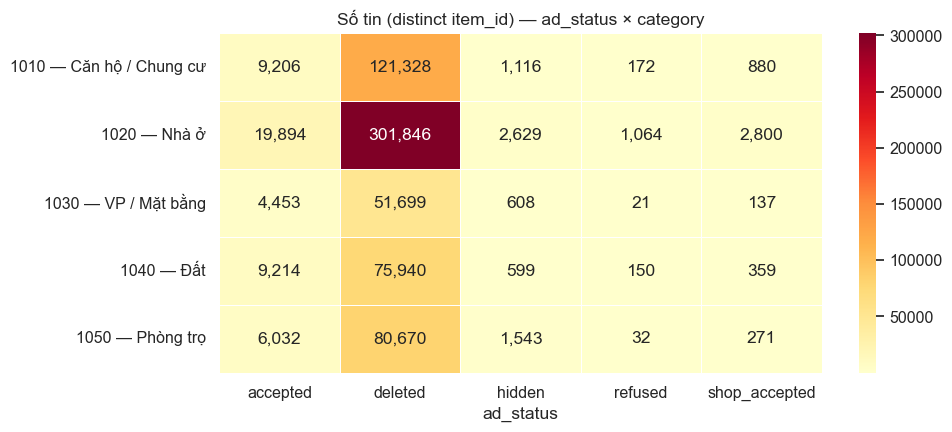

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/figs/06_ad_status_by_category_heatmap.png


In [30]:

status_by_cat = con.execute("""
    SELECT category, ad_status, COUNT(DISTINCT item_id)::BIGINT AS n_items
    FROM dim_snap
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

total_shop = float(
    status_by_cat.loc[status_by_cat["ad_status"] == "shop_accepted", "n_items"].sum()
)
status_by_cat["pct_within_category"] = (
    status_by_cat["n_items"]
    / status_by_cat.groupby("category")["n_items"].transform("sum")
    * 100.0
)
status_by_cat["pct_of_all_shop"] = np.where(
    status_by_cat["ad_status"] == "shop_accepted",
    status_by_cat["n_items"] / total_shop * 100.0 if total_shop else 0.0,
    np.nan,
)
status_by_cat = add_category_labels(status_by_cat)
export_df(status_by_cat, "06_ad_status_by_category.csv")
display(status_by_cat.pivot_table(index="category_label", columns="ad_status", values="n_items", fill_value=0))

# Heatmap
pivot_n = status_by_cat.pivot_table(index="category_label", columns="ad_status", values="n_items", fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(pivot_n, annot=True, fmt=",.0f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Số tin (distinct item_id) — ad_status × category")
ax.set_xlabel("ad_status")
ax.set_ylabel("")
show_and_save_mpl("06_ad_status_by_category_heatmap.png", fig)


## 7. Deep-dive `shop_accepted` theo category

### 7a. Profiling dim


Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/07_shop_profile_by_category.csv
Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/07_shop_city_top_by_category.csv


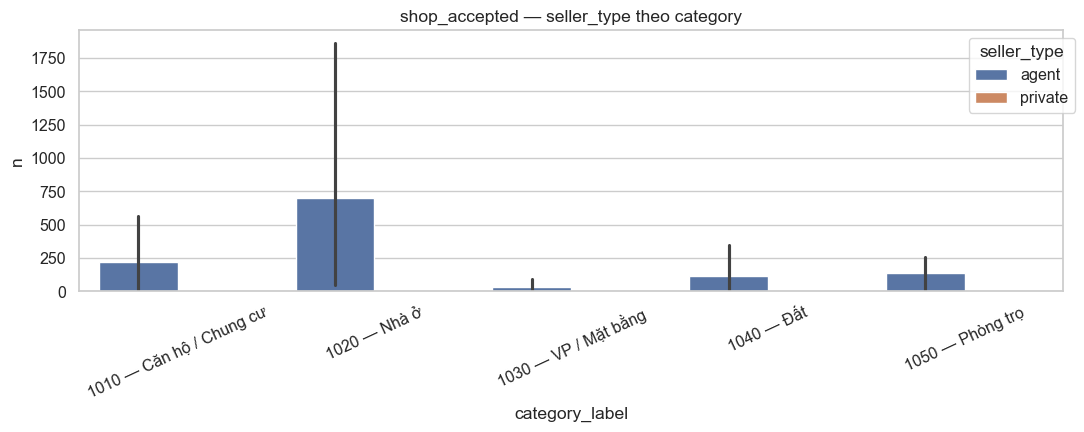

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/figs/07_shop_seller_type_by_category.png


In [31]:

shop_prof = con.execute("""
    SELECT category, seller_type, ad_type, posted_cohort,
           COUNT(*)::BIGINT AS n
    FROM dim_snap
    WHERE ad_status = 'shop_accepted'
    GROUP BY 1, 2, 3, 4
    ORDER BY 1, n DESC
""").df()
shop_prof = add_category_labels(shop_prof)
export_df(shop_prof, "07_shop_profile_by_category.csv")

shop_city = con.execute("""
    WITH ranked AS (
        SELECT category, city_name, COUNT(*)::BIGINT AS n,
               ROW_NUMBER() OVER (PARTITION BY category ORDER BY COUNT(*) DESC) AS rn
        FROM dim_snap
        WHERE ad_status = 'shop_accepted' AND city_name IS NOT NULL AND LENGTH(city_name) > 0
        GROUP BY 1, 2
    )
    SELECT category, city_name, n
    FROM ranked WHERE rn <= 15
    ORDER BY category, n DESC
""").df()
shop_city = add_category_labels(shop_city)
export_df(shop_city, "07_shop_city_top_by_category.csv")

cats_show = shop_prof.groupby("category")["n"].sum()
cats_show = cats_show[cats_show >= MIN_N_PER_CAT].index.tolist()
if cats_show:
    sub = shop_prof[shop_prof["category"].isin(cats_show)]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    sns.barplot(data=sub, x="category_label", y="n", hue="seller_type", ax=ax)
    ax.set_title("shop_accepted — seller_type theo category")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="seller_type", bbox_to_anchor=(1.02, 1))
    show_and_save_mpl("07_shop_seller_type_by_category.png", fig)


### 7b. Snapshot KPI: `shop_accepted` vs `accepted` (theo category)

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/08_snapshot_kpi_by_category_ad_status.csv


,category,ad_status,n_items,med_share_view,med_share_contact,med_max_views,med_max_contacts,med_snap_days,category_label
0,1010,accepted,9206,0.7552,0.1290,14.0,3.0,28.0,1010 — Căn hộ / Chung cư
2,1010,shop_accepted,880,0.0132,0.0000,1.0,1.0,19.0,1010 — Căn hộ / Chung cư
3,1020,accepted,19894,0.7500,0.1250,14.0,3.0,26.0,1020 — Nhà ở
5,1020,shop_accepted,2800,0.0000,0.0000,1.0,1.0,21.0,1020 — Nhà ở
6,1030,accepted,4453,0.7347,0.1154,11.0,3.0,22.0,1030 — VP / Mặt bằng
8,1030,shop_accepted,137,0.0000,0.0000,1.0,3.0,21.0,1030 — VP / Mặt bằng
9,1040,accepted,9214,0.7000,0.1210,11.0,3.0,27.0,1040 — Đất
11,1040,shop_accepted,359,0.0476,0.0000,1.0,1.0,17.0,1040 — Đất
12,1050,accepted,6032,0.9730,0.2590,31.0,4.0,22.0,1050 — Phòng trọ
14,1050,shop_accepted,271,0.0667,0.0000,2.0,1.0,16.0,1050 — Phòng trọ


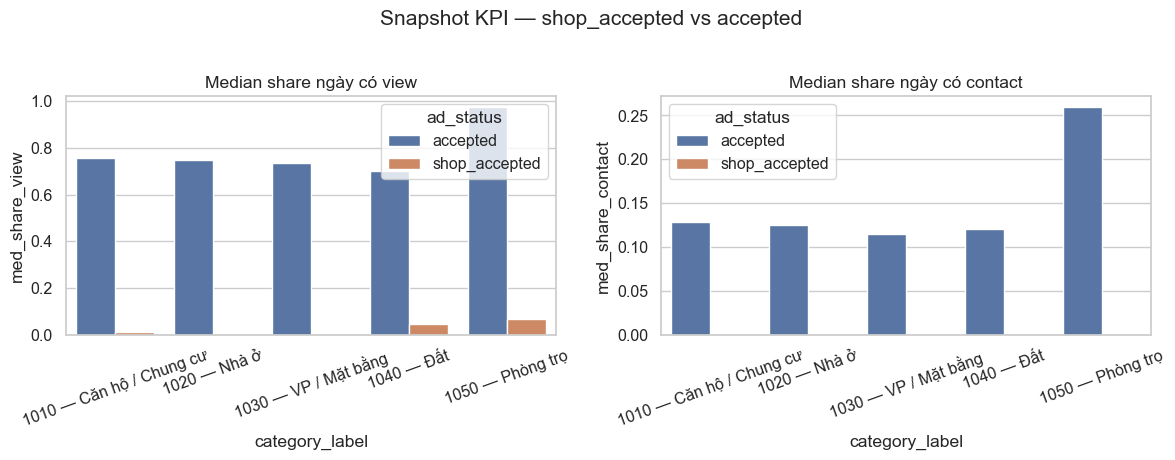

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/figs/08_snapshot_kpi_shop_vs_accepted.png


In [32]:

kpi_item = con.execute("""
    SELECT item_id, category, ad_status, n_snap_days, days_with_view, days_with_contact,
           max_views_24h, max_contacts_24h,
           days_with_view::DOUBLE / NULLIF(n_snap_days, 0) AS share_days_with_view,
           days_with_contact::DOUBLE / NULLIF(n_snap_days, 0) AS share_days_with_contact
    FROM item_snap_kpi
    WHERE ad_status IN ('shop_accepted', 'accepted', 'hidden')
""").df()

kpi_agg = (
    kpi_item.groupby(["category", "ad_status"], observed=True)
    .agg(
        n_items=("item_id", "count"),
        med_share_view=("share_days_with_view", "median"),
        med_share_contact=("share_days_with_contact", "median"),
        med_max_views=("max_views_24h", "median"),
        med_max_contacts=("max_contacts_24h", "median"),
        med_snap_days=("n_snap_days", "median"),
    )
    .reset_index()
)
kpi_agg = add_category_labels(kpi_agg)
export_df(kpi_agg, "08_snapshot_kpi_by_category_ad_status.csv")
display(kpi_agg[kpi_agg["ad_status"].isin(["shop_accepted", "accepted"])].round(4))

comp = kpi_agg[kpi_agg["ad_status"].isin(["shop_accepted", "accepted"])].copy()
if not comp.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, metric, title in zip(
        axes,
        ["med_share_view", "med_share_contact"],
        ["Median share ngày có view", "Median share ngày có contact"],
    ):
        sns.barplot(data=comp, x="category_label", y=metric, hue="ad_status", ax=ax)
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=20)
        ax.set_ylabel(metric)
    fig.suptitle("Snapshot KPI — shop_accepted vs accepted", y=1.02)
    show_and_save_mpl("08_snapshot_kpi_shop_vs_accepted.png", fig)


### 7c. Vòng đời snapshot (shop only)

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/09_shop_first_last_by_category.csv
Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/10_shop_age_paths_by_category.csv


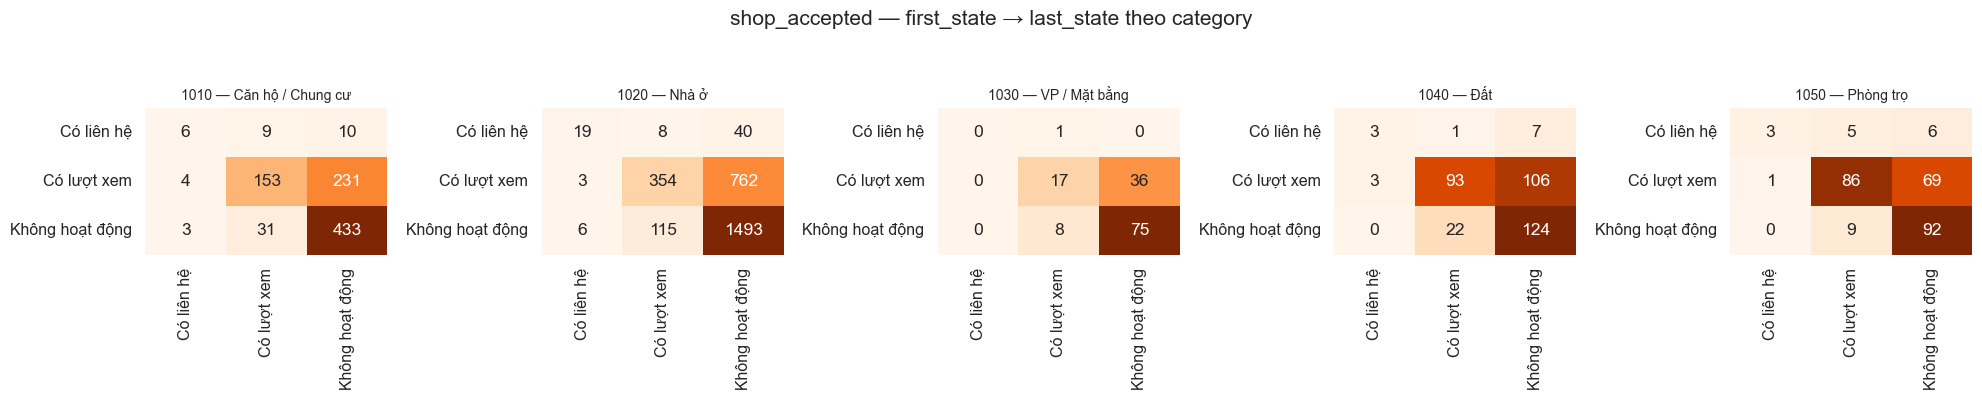

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/figs/09_shop_first_last_heatmap_by_category.png


In [33]:

shop_life = con.execute("""
    SELECT category, first_state, last_state, ad_status, COUNT(*)::BIGINT AS n
    FROM item_first_last
    WHERE ad_status = 'shop_accepted'
    GROUP BY 1, 2, 3, 4
    ORDER BY n DESC
""").df()
shop_life = add_category_labels(shop_life)
export_df(shop_life, "09_shop_first_last_by_category.csv")

shop_age = con.execute("""
    SELECT category, age_band, snap_state, ad_status, COUNT(*)::BIGINT AS n
    FROM age_state
    WHERE ad_status = 'shop_accepted'
    GROUP BY 1, 2, 3, 4
    ORDER BY n DESC
""").df()
shop_age = add_category_labels(shop_age)
export_df(shop_age, "10_shop_age_paths_by_category.csv")

# Heatmap first x last — facet categories đủ n
shop_n_cat = shop_life.groupby("category")["n"].sum()
cats_heat = shop_n_cat[shop_n_cat >= MIN_N_PER_CAT].index.tolist()
state_order = ["co_lien_he", "co_xem", "khong_hoat_dong"]
state_labels = [SNAP_STATE_VI[s] for s in state_order]

if cats_heat:
    nfac = len(cats_heat)
    fig, axes = plt.subplots(1, nfac, figsize=(4 * nfac, 3.8), squeeze=False)
    for ax, cat in zip(axes.flat, cats_heat):
        sub = shop_life[shop_life["category"] == cat]
        pv = sub.pivot_table(index="first_state", columns="last_state", values="n", fill_value=0)
        pv = pv.reindex(index=state_order, columns=state_order).fillna(0)
        pv.index = state_labels
        pv.columns = state_labels
        sns.heatmap(pv, annot=True, fmt=".0f", cmap="Oranges", ax=ax, cbar=False)
        ax.set_title(label_cat(cat), fontsize=10)
    fig.suptitle("shop_accepted — first_state → last_state theo category", y=1.05)
    show_and_save_mpl("09_shop_first_last_heatmap_by_category.png", fig)


## 8. Demand & events theo `ad_status` × `category`

Aggregate `fact_user_events` → flags/item, join `dim_snap`, coverage 4 explicit types.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/11_positive_events_by_ad_status_category.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/11b_coverage_by_ad_status_category.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/11c_shop_event_mix_by_category.csv


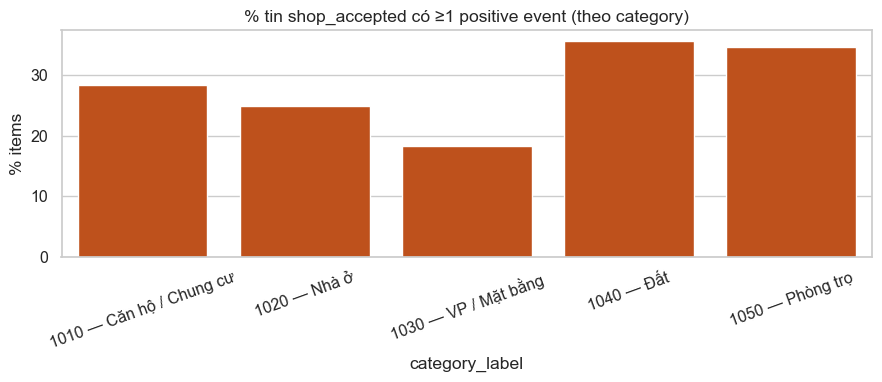

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/figs/11_shop_pct_positive_by_category.png


In [34]:

con.execute(f"""
    CREATE OR REPLACE TEMP TABLE item_pos_flags AS
    SELECT CAST(item_id AS VARCHAR) AS item_id,
           COUNT(*)::BIGINT AS n_positive_events,
           COUNT(DISTINCT user_id)::BIGINT AS n_distinct_users,
           MAX(CASE WHEN event_type = 'view_phone' THEN 1 ELSE 0 END) AS has_view_phone,
           MAX(CASE WHEN event_type = 'contact_chat' THEN 1 ELSE 0 END) AS has_contact_chat,
           MAX(CASE WHEN event_type = 'contact_zalo' THEN 1 ELSE 0 END) AS has_contact_zalo,
           MAX(CASE WHEN event_type = 'contact_sms' THEN 1 ELSE 0 END) AS has_contact_sms
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE event_type IN ({demand_pos_list})
      AND item_id IS NOT NULL
    GROUP BY 1
""")

pos_by_status = con.execute("""
    SELECT d.category, d.ad_status,
           COUNT(DISTINCT d.item_id)::BIGINT AS n_items,
           COUNT(DISTINCT CASE WHEN f.item_id IS NOT NULL THEN d.item_id END)::BIGINT AS n_items_with_event,
           COALESCE(SUM(f.n_positive_events), 0)::BIGINT AS n_events,
           COALESCE(SUM(f.n_distinct_users), 0)::BIGINT AS n_distinct_users
    FROM dim_snap d
    LEFT JOIN item_pos_flags f ON d.item_id = f.item_id
    GROUP BY 1, 2
""").df()
pos_by_status["pct_items_with_any_positive"] = (
    pos_by_status["n_items_with_event"] / pos_by_status["n_items"] * 100.0
)
pos_by_status = add_category_labels(pos_by_status)
export_df(pos_by_status, "11_positive_events_by_ad_status_category.csv")

# Coverage 4 explicit types
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE item_explicit AS
    SELECT CAST(item_id AS VARCHAR) AS item_id,
           MAX(CASE WHEN event_type = 'view_phone' THEN 1 ELSE 0 END)
           + MAX(CASE WHEN event_type = 'contact_chat' THEN 1 ELSE 0 END)
           + MAX(CASE WHEN event_type = 'contact_zalo' THEN 1 ELSE 0 END)
           + MAX(CASE WHEN event_type = 'contact_sms' THEN 1 ELSE 0 END) AS n_explicit_types
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE event_type IN ({explicit_list}) AND item_id IS NOT NULL
    GROUP BY 1
""")

coverage = con.execute("""
    SELECT d.category, d.ad_status,
           CASE
             WHEN e.item_id IS NULL THEN 'no_events'
             WHEN e.n_explicit_types = 0 THEN 'zero_explicit'
             WHEN e.n_explicit_types = 4 THEN 'full_four'
             ELSE 'partial_1_3'
           END AS coverage_group,
           COUNT(*)::BIGINT AS n_listings
    FROM dim_snap d
    LEFT JOIN item_explicit e ON d.item_id = e.item_id
    GROUP BY 1, 2, 3
""").df()
coverage["pct_within_status_cat"] = (
    coverage["n_listings"]
    / coverage.groupby(["category", "ad_status"])["n_listings"].transform("sum")
    * 100.0
)
coverage = add_category_labels(coverage)
export_df(coverage, "11b_coverage_by_ad_status_category.csv")

# shop: event mix x login per category
shop_ev = con.execute(f"""
    SELECT d.category, e.is_login, e.event_type, COUNT(*)::BIGINT AS n_events
    FROM read_parquet('{EVENTS_GLOB}') e
    INNER JOIN dim_snap d ON CAST(e.item_id AS VARCHAR) = d.item_id
    WHERE d.ad_status = 'shop_accepted'
      AND e.event_type IN ({demand_pos_list})
    GROUP BY 1, 2, 3
""").df()
shop_ev = add_category_labels(shop_ev)
export_df(shop_ev, "11c_shop_event_mix_by_category.csv")

shop_pct = pos_by_status[pos_by_status["ad_status"] == "shop_accepted"].copy()
if not shop_pct.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(data=shop_pct, x="category_label", y="pct_items_with_any_positive", color="#d94801", ax=ax)
    ax.set_title("% tin shop_accepted có ≥1 positive event (theo category)")
    ax.set_ylabel("% items")
    ax.tick_params(axis="x", rotation=20)
    show_and_save_mpl("11_shop_pct_positive_by_category.png", fig)


## 9. Seller concentration — `shop_accepted`

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/12_shop_seller_hhi_by_category.csv


,category,n_sellers,n_listings,top1_seller_share_pct,hhi,category_label
0,1010,130.0,880.0,10.455,0.036,1010 — Căn hộ / Chung cư
1,1020,253.0,2800.0,7.964,0.024,1020 — Nhà ở
2,1030,37.0,137.0,16.058,0.076,1030 — VP / Mặt bằng
3,1040,78.0,359.0,16.435,0.056,1040 — Đất
4,1050,64.0,271.0,8.487,0.038,1050 — Phòng trọ


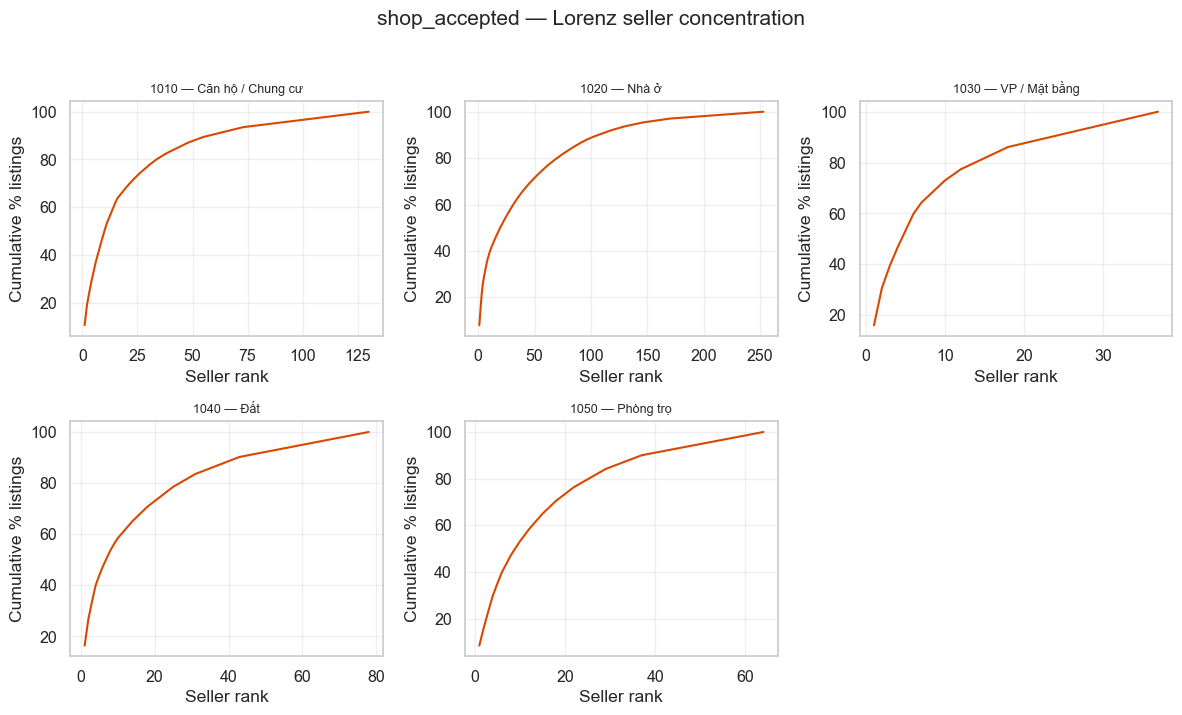

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/figs/12_shop_seller_lorenz_by_category.png


In [35]:

seller_shop = con.execute("""
    SELECT category, seller_id, COUNT(*)::BIGINT AS n_listings
    FROM dim_snap
    WHERE ad_status = 'shop_accepted' AND seller_id IS NOT NULL
    GROUP BY 1, 2
""").df()

def hhi_and_top1(grp: pd.DataFrame) -> pd.Series:
    shares = grp["n_listings"] / grp["n_listings"].sum()
    return pd.Series({
        "n_sellers": len(grp),
        "n_listings": int(grp["n_listings"].sum()),
        "top1_seller_share_pct": float(shares.max() * 100.0),
        "hhi": float((shares ** 2).sum()),
    })

hhi_rows = seller_shop.groupby("category", observed=True).apply(hhi_and_top1, include_groups=False).reset_index()
hhi_rows = add_category_labels(hhi_rows)
export_df(hhi_rows, "12_shop_seller_hhi_by_category.csv")
display(hhi_rows.round(3))

cats_lorenz = hhi_rows[hhi_rows["n_listings"] >= MIN_N_PER_CAT]["category"].tolist()
if cats_lorenz:
    ncol = min(3, len(cats_lorenz))
    nrow = int(np.ceil(len(cats_lorenz) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.5 * nrow), squeeze=False)
    for ax, cat in zip(axes.flat, cats_lorenz):
        g = seller_shop[seller_shop["category"] == cat].sort_values("n_listings", ascending=False)
        cum = g["n_listings"].cumsum() / g["n_listings"].sum() * 100.0
        ax.plot(np.arange(1, len(cum) + 1), cum.values, color="#d94801")
        ax.set_title(label_cat(cat), fontsize=9)
        ax.set_xlabel("Seller rank")
        ax.set_ylabel("Cumulative % listings")
        ax.grid(True, alpha=0.3)
    for ax in axes.flat[len(cats_lorenz):]:
        ax.set_visible(False)
    fig.suptitle("shop_accepted — Lorenz seller concentration", y=1.02)
    show_and_save_mpl("12_shop_seller_lorenz_by_category.png", fig)


---
## 9b. Nhóm **seller** — `shop_accepted`

| `seller_group` | Ý nghĩa |
|----------------|---------|
| `shop_and_accepted` | Có ≥1 tin shop và ≥1 tin accepted |
| `shop_only` | Chỉ shop |
| `shop_and_hidden` | Shop + hidden, không accepted |


In [ ]:

colors_g = {
    "shop_and_accepted": "#238b45",
    "shop_only": "#d94801",
    "shop_and_hidden": "#6a51a3",
}
order_g = ["shop_and_accepted", "shop_only", "shop_and_hidden"]

seller_dim = con.execute("""
    WITH seller_flags AS (
        SELECT seller_id, seller_type,
               MAX(CASE WHEN ad_status = 'shop_accepted' THEN 1 ELSE 0 END) AS has_shop,
               MAX(CASE WHEN ad_status = 'accepted' THEN 1 ELSE 0 END) AS has_acc,
               MAX(CASE WHEN ad_status = 'hidden' THEN 1 ELSE 0 END) AS has_hid,
               COUNT(*) FILTER (WHERE ad_status = 'shop_accepted') AS n_shop,
               COUNT(*) FILTER (WHERE ad_status = 'accepted') AS n_acc,
               COUNT(*) FILTER (WHERE ad_status = 'deleted') AS n_del
        FROM dim_snap
        WHERE seller_id IS NOT NULL
        GROUP BY 1, 2
    )
    SELECT seller_id, seller_type,
           CASE
             WHEN has_shop = 1 AND has_acc = 1 THEN 'shop_and_accepted'
             WHEN has_shop = 1 AND has_hid = 1 AND has_acc = 0 THEN 'shop_and_hidden'
             WHEN has_shop = 1 THEN 'shop_only'
             ELSE 'other'
           END AS seller_group,
           n_shop, n_acc, n_del
    FROM seller_flags
    WHERE has_shop = 1
""").df()
export_df(seller_dim, "13_shop_seller_groups.csv")

shop_by_group = (
    seller_dim.groupby("seller_group", observed=True)
    .agg(n_sellers=("seller_id", "nunique"), n_shop_listings=("n_shop", "sum"))
    .reset_index()
)
shop_by_group["pct_listings"] = pct_share(shop_by_group["n_shop_listings"])
display(shop_by_group.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sub = shop_by_group.set_index("seller_group").reindex([g for g in order_g if g in shop_by_group.seller_group.values])
axes[0].bar(sub.index, sub["n_shop_listings"], color=[colors_g.get(x, "#999") for x in sub.index])
axes[0].set_title("Số tin shop_accepted"); axes[0].tick_params(axis="x", rotation=15)
axes[1].bar(sub.index, sub["n_sellers"], color=[colors_g.get(x, "#999") for x in sub.index])
axes[1].set_title("Số seller"); axes[1].tick_params(axis="x", rotation=15)
fig.suptitle("shop_accepted — phân nhóm seller", y=1.02)
show_and_save_mpl("13_shop_seller_group_counts.png", fig)

shop_list = con.execute("""
    SELECT category, seller_id FROM dim_snap
    WHERE ad_status = 'shop_accepted' AND seller_id IS NOT NULL
""").df().merge(seller_dim[["seller_id", "seller_group"]], on="seller_id")
sg_cat = shop_list.groupby(["category", "seller_group"], observed=True).size().reset_index(name="n")
sg_cat = add_category_labels(sg_cat)
sg_pivot = sg_cat.pivot_table(index="category_label", columns="seller_group", values="n", fill_value=0)
sg_pct = sg_pivot.div(sg_pivot.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
sg_pct[[c for c in order_g if c in sg_pct.columns]].plot(
    kind="bar", stacked=True, ax=ax,
    color=[colors_g.get(c, "#999") for c in sg_pct.columns if c in order_g],
)
ax.set_title("Mix seller_group — tin shop theo category (%)")
ax.set_ylabel("% tin shop"); ax.legend(title="seller_group", bbox_to_anchor=(1.02, 1))
ax.tick_params(axis="x", rotation=20)
show_and_save_mpl("13_shop_seller_group_by_category.png", fig)

lpd = con.execute("""
    SELECT ad_status, seller_id, COUNT(*)::BIGINT AS n
    FROM dim_snap
    WHERE seller_id IS NOT NULL AND seller_type = 'agent'
      AND ad_status IN ('shop_accepted', 'accepted')
    GROUP BY 1, 2
""").df()
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=lpd, x="ad_status", y="n", hue="ad_status", ax=ax, legend=False,
            palette={"shop_accepted": "#d94801", "accepted": "#238b45"})
ax.set_yscale("symlog")
ax.set_title("Tin / seller (agent) — symlog")
show_and_save_mpl("13_listings_per_seller_agent_box.png", fig)


---
## 12. Phân tích theo **city**

Top thành phố, so sánh shop vs accepted, mix seller_group, % positive event theo city (cần section 8).


In [ ]:

TOP_CITY_N = 12
MIN_CITY_SHOP = 15

city_shop = con.execute("""
    SELECT category, city_name,
           COUNT(*)::BIGINT AS n_shop,
           COUNT(DISTINCT seller_id)::BIGINT AS n_sellers
    FROM dim_snap
    WHERE ad_status = 'shop_accepted'
      AND city_name IS NOT NULL AND LENGTH(TRIM(city_name)) > 0
    GROUP BY 1, 2
""").df()
city_shop = add_category_labels(city_shop)
export_df(city_shop.sort_values(["category", "n_shop"], ascending=[True, False]),
          "14_shop_by_city_category.csv")

city_all = (
    city_shop.groupby("city_name", observed=True)
    .agg(n_shop=("n_shop", "sum"), n_sellers=("n_sellers", "sum"))
    .reset_index()
    .sort_values("n_shop", ascending=False)
)
city_all["pct_of_shop"] = city_all["n_shop"] / city_all["n_shop"].sum() * 100
export_df(city_all.head(30), "14_shop_top_cities.csv")
top_cities = city_all.head(TOP_CITY_N)["city_name"].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
sub = city_all.head(TOP_CITY_N).sort_values("n_shop")
ax.barh(sub["city_name"], sub["n_shop"], color="#d94801")
ax.set_title(f"Top {TOP_CITY_N} TP — tin shop_accepted")
ax.set_xlabel("n listings")
for i, (_, row) in enumerate(sub.iterrows()):
    ax.text(row["n_shop"], i, f"  {row['pct_of_shop']:.1f}%", va="center", fontsize=8)
show_and_save_mpl("14_shop_top_cities_barh.png", fig)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), squeeze=False)
for ax, cat in zip(axes.flat, CAT_ORDER):
    g = city_shop[city_shop["category"] == cat].nlargest(8, "n_shop")
    if g.empty:
        ax.set_visible(False)
        continue
    ax.barh(g["city_name"], g["n_shop"], color="#fd8d3c")
    ax.set_title(label_cat(cat), fontsize=9)
fig.suptitle("Top cities — shop theo category", y=1.02)
show_and_save_mpl("14_shop_top_cities_by_category_facets.png", fig)

city_compare = con.execute("""
    SELECT category, city_name, ad_status, COUNT(*)::BIGINT AS n
    FROM dim_snap
    WHERE ad_status IN ('shop_accepted', 'accepted')
      AND city_name IS NOT NULL AND LENGTH(TRIM(city_name)) > 0
    GROUP BY 1, 2, 3
""").df()
pv_city = city_compare.pivot_table(index="city_name", columns="ad_status", values="n", fill_value=0).reset_index()
pv_city["n_shop"] = pv_city.get("shop_accepted", 0)
pv_city["n_acc"] = pv_city.get("accepted", 0)
pv_city["shop_share_pct"] = pv_city["n_shop"] / (pv_city["n_shop"] + pv_city["n_acc"]).replace(0, np.nan) * 100
glob = pv_city[pv_city["n_shop"] >= MIN_CITY_SHOP].sort_values("n_shop", ascending=False)
display(glob.head(15).round(2))
export_df(glob, "14_city_shop_share_vs_accepted.csv")

fig, ax = plt.subplots(figsize=(9, 5))
plot_s = glob.head(TOP_CITY_N).sort_values("shop_share_pct")
ax.barh(plot_s["city_name"], plot_s["shop_share_pct"], color="#6baed6")
ax.set_xlabel("% shop trong (shop + accepted) — gộp category theo city")
ax.set_title("Tỷ lệ shop_accepted theo thành phố")
show_and_save_mpl("14_city_shop_share_pct.png", fig)

c1020 = city_compare[city_compare["category"] == 1020]
pv = c1020.pivot_table(index="city_name", columns="ad_status", values="n", fill_value=0)
pv["shop_share_pct"] = pv.get("shop_accepted", 0) / (pv.get("shop_accepted", 0) + pv.get("accepted", 0)) * 100
pv = pv[pv.get("shop_accepted", 0) >= 10].sort_values("shop_accepted", ascending=False).head(15)
display(pv.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
plot = pv.sort_values("shop_share_pct").tail(12)
ax.scatter(plot["accepted"], plot["shop_accepted"], s=80, c="#d94801", alpha=0.85)
for name in plot.index:
    if name in ("Tp Hồ Chí Minh", "Hà Nội", "Đà Nẵng", "Cần Thơ", "Đồng Nai", "Long An", "Bình Dương"):
        ax.annotate(name, (plot.loc[name, "accepted"], plot.loc[name, "shop_accepted"]), fontsize=8)
ax.set_xlabel("n accepted"); ax.set_ylabel("n shop_accepted")
ax.set_title("1020 Nhà ở — shop vs accepted theo city")
show_and_save_mpl("14_city_1020_shop_vs_accepted_scatter.png", fig)

shop_city_sg = con.execute("""
    SELECT city_name, seller_id, COUNT(*)::BIGINT AS n
    FROM dim_snap
    WHERE ad_status = 'shop_accepted' AND seller_id IS NOT NULL AND city_name IS NOT NULL
    GROUP BY 1, 2
""").df().merge(seller_dim[["seller_id", "seller_group"]], on="seller_id")
mix_city = shop_city_sg.groupby(["city_name", "seller_group"], observed=True)["n"].sum().reset_index()
mix_city = mix_city[mix_city["city_name"].isin(top_cities)]
mix_pct = mix_city.pivot_table(index="city_name", columns="seller_group", values="n", fill_value=0)
mix_pct = mix_pct.div(mix_pct.sum(axis=1), axis=0) * 100
mix_pct = mix_pct.loc[city_all.set_index("city_name").loc[top_cities].index]

fig, ax = plt.subplots(figsize=(10, 5))
cols = [c for c in order_g if c in mix_pct.columns]
mix_pct[cols].sort_values(cols[0] if cols else "shop_only", ascending=True).plot(
    kind="barh", stacked=True, ax=ax, color=[colors_g.get(c, "#999") for c in cols],
)
ax.set_title("Mix seller_group — top cities")
ax.set_xlabel("% tin shop"); ax.legend(title="seller_group", bbox_to_anchor=(1.02, 1))
show_and_save_mpl("14_city_seller_group_mix.png", fig)

try:
    con.execute("SELECT 1 FROM item_pos_flags LIMIT 1")
    pos_city = con.execute("""
        SELECT d.city_name,
               COUNT(DISTINCT d.item_id)::BIGINT AS n_shop,
               COUNT(DISTINCT CASE WHEN f.item_id IS NOT NULL THEN d.item_id END)::BIGINT AS n_with_pos
        FROM dim_snap d
        LEFT JOIN item_pos_flags f ON d.item_id = f.item_id
        WHERE d.ad_status = 'shop_accepted' AND d.city_name IS NOT NULL
        GROUP BY 1
        HAVING COUNT(*) >= 10
    """).df()
    pos_city["pct_positive"] = pos_city["n_with_pos"] / pos_city["n_shop"] * 100
    pos_city = pos_city.sort_values("n_shop", ascending=False)
    export_df(pos_city, "14_shop_positive_rate_by_city.csv")
    fig, ax = plt.subplots(figsize=(10, 5))
    sub = pos_city.head(TOP_CITY_N).sort_values("pct_positive")
    ax.barh(sub["city_name"], sub["pct_positive"], color="#74c476")
    ax.set_xlabel("% tin shop có ≥1 positive event")
    ax.set_title("Demand — shop theo city")
    show_and_save_mpl("14_shop_positive_rate_by_city.png", fig)
except duckdb.CatalogException:
    print("Chạy section 8 trước để có item_pos_flags.")


## 10. Charts tổng hợp & Sankey shop (MIN_FLOW thấp)

Bar `shop_accepted` share trong từng category; Sankey snapshot_state → shop (top categories).


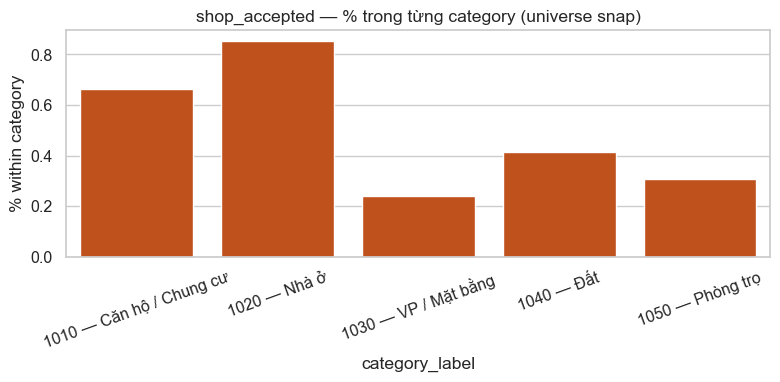

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_ad_status_sankey/figs/10_shop_share_within_category.png
PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



PNG bỏ qua (pip install kaleido): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



In [36]:

# % shop trong từng category
shop_share = status_by_cat[status_by_cat["ad_status"] == "shop_accepted"][
    ["category", "category_label", "n_items", "pct_within_category"]
].copy()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=shop_share, x="category_label", y="pct_within_category", color="#d94801", ax=ax)
ax.set_title("shop_accepted — % trong từng category (universe snap)")
ax.set_ylabel("% within category")
ax.tick_params(axis="x", rotation=20)
show_and_save_mpl("10_shop_share_within_category.png", fig)

# Sankey: last snap_state → shop_accepted (global + top 2 categories)
top_cats = (
    shop_prof.groupby("category")["n"].sum().sort_values(ascending=False).head(2).index.tolist()
)
for cat_filter, suffix in [(None, "all"), *[(c, f"_cat{c}") for c in top_cats]]:
    q = """
        SELECT last_state AS source, ad_status AS target, COUNT(*)::BIGINT AS n
        FROM item_first_last
        WHERE ad_status = 'shop_accepted'
    """
    params = []
    if cat_filter is not None:
        q += " AND category = ?"
        params.append(int(cat_filter))
    q += " GROUP BY 1, 2"
    flows = con.execute(q, params).df()
    if flows.empty:
        continue
    flows["source"] = flows["source"].map(lambda x: SNAP_STATE_VI.get(x, x))
    flows["target"] = flows["target"].map(label_ad)
    fig_sk, used = flows_to_sankey(flows, "source", "target", min_flow=MIN_FLOW_SHOP)
    title_cat = " (all categories)" if cat_filter is None else f" — {label_cat(cat_filter)}"
    fig_sk.update_layout(title=f"Sankey shop — last snapshot state → ad_status{title_cat}")
    show_and_save(fig_sk, f"10_sankey_shop_last_state{suffix}", height=520)
    fig_sk


---
## 11. Tóm tắt insight (theo category)

Chạy cell dưới để in số liệu mới nhất từ `outputs/eda_ad_status_sankey/*.csv`.

**Đã kiểm chứng (universe = tin có snapshot, ~4.447 `shop_accepted`):**

| Category | shop_accepted | % trong category | % của toàn bộ shop | % tin shop có positive event |
|----------|---------------|------------------|--------------------|------------------------------|
| 1010 Căn hộ | 880 | 0.66% | 19.8% | 28.4% |
| 1020 Nhà ở | 2.800 | 0.85% | **63.0%** | 25.0% |
| 1030 VP/MB | 137 | 0.24% | 3.1% | 18.2% |
| 1040 Đất | 359 | 0.42% | 8.1% | 35.7% |
| 1050 Phòng trọ | 271 | 0.31% | 6.1% | 34.7% |

**Pattern chính:**
- `shop_accepted` gần như **không có contact** trên snapshot (median `share_days_with_contact` = 0 mọi category); median share ngày có view **rất thấp** (0–7%) so với `accepted` (~70–97%).
- **96–97%** tin shop ở 1010/1020 có `coverage_group = no_events` (không có dòng event trong cửa sổ EDA).
- Vòng đời snapshot: đa số `khong_hoat_dong → khong_hoat_dong` (đặc biệt 1020).
- Seller concentration vừa phải (top-1 seller ~8–16% theo category).

**Seller (section 9b):** ~99% agent; **83%** tin shop từ seller cũng có `accepted` trên dim (`shop_and_accepted`).

**City (section 12):** **Tp Hồ Chí Minh** ~3.674 tin shop (**~83%**); Đà Nẵng ~302. Trong HCMC+accepted gộp, shop ~**15%** volume (2.529 / 16.472 ở 1020). % tin shop có positive event cao nhất ở **1040/1050** (~35%), thấp ở **1030** (~18%).

Biểu đồ: `figs/06_*` … `figs/14_*`, `figs/13_*` · CSV: `13_shop_seller_groups.csv`, `14_shop_top_cities.csv`, …


In [37]:

def _load(name: str) -> pd.DataFrame:
    return pd.read_csv(OUT_DIR / name)

s6 = _load("06_ad_status_by_category.csv")
s7 = _load("07_shop_profile_by_category.csv")
s8 = _load("08_snapshot_kpi_by_category_ad_status.csv")
s11 = _load("11_positive_events_by_ad_status_category.csv")
s12 = _load("12_shop_seller_hhi_by_category.csv")

total_shop = int(s6.loc[s6["ad_status"] == "shop_accepted", "n_items"].sum())
print(f"Tổng shop_accepted (có snapshot): {total_shop:,} tin\n")

for cat in CAT_ORDER:
    lbl = label_cat(cat)
    n_cat = int(s6.loc[s6["category"] == cat, "n_items"].sum())
    n_shop = int(s6.loc[(s6["category"] == cat) & (s6["ad_status"] == "shop_accepted"), "n_items"].sum())
    pct_cat = n_shop / total_shop * 100 if total_shop else 0
    pct_within = n_shop / n_cat * 100 if n_cat else 0

    pos = s11[(s11["category"] == cat) & (s11["ad_status"] == "shop_accepted")]
    pct_pos = float(pos["pct_items_with_any_positive"].iloc[0]) if len(pos) else float("nan")

    k_shop = s8[(s8["category"] == cat) & (s8["ad_status"] == "shop_accepted")]
    k_acc = s8[(s8["category"] == cat) & (s8["ad_status"] == "accepted")]
    med_v = float(k_shop["med_share_view"].iloc[0]) if len(k_shop) else float("nan")
    med_v_acc = float(k_acc["med_share_view"].iloc[0]) if len(k_acc) else float("nan")

    dom = s7[(s7["category"] == cat)].sort_values("n", ascending=False).head(1)
    dom_seller = dom["seller_type"].iloc[0] if len(dom) else "—"
    dom_ad = dom["ad_type"].iloc[0] if len(dom) else "—"

    h = s12[s12["category"] == cat]
    top1 = float(h["top1_seller_share_pct"].iloc[0]) if len(h) else float("nan")

    print(f"**{lbl}**")
    print(f"  - shop_accepted: {n_shop:,} tin ({pct_within:.2f}% trong category; {pct_cat:.1f}% của toàn bộ shop)")
    print(f"  - % tin shop có positive event: {pct_pos:.1f}%")
    print(f"  - median share ngày có view: shop={med_v:.3f} vs accepted={med_v_acc:.3f}")
    print(f"  - profile chủ đạo: seller_type={dom_seller}, ad_type={dom_ad}")
    print(f"  - top-1 seller share: {top1:.1f}%")
    print()


Tổng shop_accepted (có snapshot): 4,447 tin

**1010 — Căn hộ / Chung cư**
  - shop_accepted: 880 tin (0.66% trong category; 19.8% của toàn bộ shop)
  - % tin shop có positive event: 28.4%
  - median share ngày có view: shop=0.013 vs accepted=0.755
  - profile chủ đạo: seller_type=agent, ad_type=let
  - top-1 seller share: 10.5%

**1020 — Nhà ở**
  - shop_accepted: 2,800 tin (0.85% trong category; 63.0% của toàn bộ shop)
  - % tin shop có positive event: 25.0%
  - median share ngày có view: shop=0.000 vs accepted=0.750
  - profile chủ đạo: seller_type=agent, ad_type=sell
  - top-1 seller share: 8.0%

**1030 — VP / Mặt bằng**
  - shop_accepted: 137 tin (0.24% trong category; 3.1% của toàn bộ shop)
  - % tin shop có positive event: 18.2%
  - median share ngày có view: shop=0.000 vs accepted=0.735
  - profile chủ đạo: seller_type=agent, ad_type=let
  - top-1 seller share: 16.1%

**1040 — Đất**
  - shop_accepted: 359 tin (0.42% trong category; 8.1% của toàn bộ shop)
  - % tin shop có positi